<a href="https://colab.research.google.com/github/varshitfauzdar/NLP_Assignments/blob/main/Deep_Learning_for_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import random
import string
import numpy as np

#Q1 — Character-Level RNN (Name Generator)
---
Train an RNN that learns character patterns in names and generates new names.

##PIPELINE
<div properties = "text-align-center">
Names Dataset </br>
↓</br>
Character Vocabulary </br>
↓</br>
One-Hot Encoding</br>
↓</br>
RNN Model</br>
↓</br>
Predict Next Character</br>
↓</br>
Generate New Names
</div>

In [ ]:
import nltk
nltk.download('names')

from nltk.corpus import names

names_list = names.words()

names = [n.lower() for n in names_list]

#Create Character Vocabulary

chars = sorted(list(set("".join(names))))
chars.append(".")  # end token

char_to_ix = {ch:i for i,ch in enumerate(chars)}
ix_to_char = {i:ch for ch,i in char_to_ix.items()}

vocab_size = len(chars)

print("Characters:", chars)
print("Vocabulary size:", vocab_size)

[nltk_data] Downloading package names to /root/nltk_data...


Characters: [' ', "'", '-', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '.']
Vocabulary size: 30


[nltk_data]   Unzipping corpora/names.zip.


In [ ]:
# OneHot Encoding

def char_to_tensor(char):
    tensor = torch.zeros(1, vocab_size)
    tensor[0][char_to_ix[char]] = 1
    return tensor

#Prepare Training Sequence
def name_to_tensors(name):
    inputs = [char_to_tensor(c) for c in name]
    targets = [char_to_ix[c] for c in name[1:]] + [char_to_ix["."]]
    return inputs, targets


In [ ]:
#Build RNN Model

class CharRNN(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):

        combined = torch.cat((input, hidden), 1)

        hidden = self.i2h(combined)
        output = self.i2o(combined)

        output = self.softmax(output)

        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

In [ ]:
hidden_size = 256

model = CharRNN(vocab_size, hidden_size, vocab_size)

criterion = nn.NLLLoss()

learning_rate = 0.005

In [ ]:
def train(name):

    hidden = model.init_hidden()

    inputs, targets = name_to_tensors(name)

    loss = 0

    for i in range(len(inputs)):

        output, hidden = model(inputs[i], hidden)

        l = criterion(output, torch.tensor([targets[i]]))

        loss += l

    model.zero_grad()

    loss.backward()

    for p in model.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return loss.item() / len(inputs)

In [ ]:
for epoch in range(5000):

    name = random.choice(names)

    loss = train(name)

    if epoch % 500 == 0:
        print(epoch, loss)

0 3.371335983276367
500 2.977545166015625
1000 2.6527312596639
1500 2.781183624267578
2000 2.928396542867025
2500 2.268762969970703
3000 1.66592009862264
3500 2.3375110626220703
4000 1.8557243347167969
4500 2.719606399536133


In [ ]:
#Generate New Names
def generate(start_char="a", max_len=10):

    hidden = model.init_hidden()
    input = char_to_tensor(start_char)

    name = start_char

    for i in range(max_len):

        output, hidden = model(input, hidden)

        probs = torch.exp(output)
        top_i = torch.multinomial(probs, 1).item()

        char = ix_to_char[top_i]

        if char == ".":
            break

        name += char
        input = char_to_tensor(char)

    return name

In [ ]:
for i in range(10):
    print(generate("a"))

ardalia
annisele
ahriane
arbzea
arine
apml
amgn
argaen
aaryyn
ailon


#Q2 — LSTM Sentiment Classification
---
Classify movie review as Positve(1) or Negative(0)

---
##PIPELINE

IMDB Dataset </br>
↓</br>
Tokenization</br>
↓</br>
Word Index Mapping</br>
↓</br>
Padding Sequences</br>
↓</br>
Embedding Layer</br>
↓</br>
LSTM</br>
↓</br>
Dense Layer</br>
↓</br>
Sigmoid Output</br>

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [ ]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


In [ ]:
print("Example review (encoded):")
print(X_train[2])

print("Label:", y_train[2])

Example review (encoded):
[1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 5974, 54, 61, 369, 13, 71, 149, 14, 22, 112, 4, 2401, 311, 12, 16, 3711, 33, 75, 43, 1829, 296, 4, 86, 320, 35, 534, 19, 263, 4821, 1301, 4, 1873, 33, 89, 78, 12, 66, 16, 4, 360, 7, 4, 58, 316, 334, 11, 4, 1716, 43, 645, 662, 8, 257, 85, 1200, 42, 1228, 2578, 83, 68, 3912, 15, 36, 165, 1539, 278, 36, 69, 2, 780, 8, 106, 14, 6905, 1338, 18, 6, 22, 12, 215, 28, 610, 40, 6, 87, 326, 23, 2300, 21, 23, 22, 12, 272, 40, 57, 31, 11, 4, 22, 47, 6, 2307, 51, 9, 170, 23, 595, 116, 595, 1352, 13, 191, 79, 638, 89, 2, 14, 9, 8, 106, 607, 624, 35, 534, 6, 227, 7, 129, 113]
Label: 0


In [ ]:
# Sequence padding
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("Shape after padding:", X_train.shape)

Shape after padding: (25000, 200)


In [ ]:
#LSTM MODEL

model = Sequential([

    Embedding(input_dim=vocab_size, output_dim=256, input_length=max_length),

    LSTM(32, return_sequences=False),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# model.summary()

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6671 - loss: 0.5935 - val_accuracy: 0.8546 - val_loss: 0.3514
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9007 - loss: 0.2602 - val_accuracy: 0.8640 - val_loss: 0.3173
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9403 - loss: 0.1741 - val_accuracy: 0.8724 - val_loss: 0.3382
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9551 - loss: 0.1359 - val_accuracy: 0.8746 - val_loss: 0.3538
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9694 - loss: 0.1013 - val_accuracy: 0.8668 - val_loss: 0.3991


In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8587 - loss: 0.4306
Test Accuracy: 0.8596400022506714


In [ ]:
# Predict Sentiment of a Review
word_index = imdb.get_word_index()

reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(text):
    return " ".join([reverse_word_index.get(i-3, "?") for i in text])

In [ ]:
prediction = model.predict(X_test[0].reshape(1,200))

print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Prediction: [[0.01712532]]


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,791,077 (29.72 MB)

 Trainable params: 2,597,025 (9.91 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,194,052 (19.81 MB)

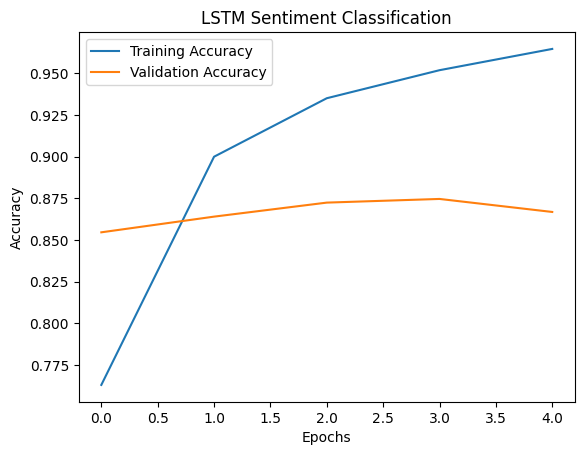

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("LSTM Sentiment Classification")

plt.legend()
plt.show()